# Day 5 — Full Evaluation, Explainability & Sprint Review
## Melanoma Skin Cancer — Benign vs Malignant

### Sprint 3 Close-Out

This notebook completes Sprint 3 for the **Melanoma Skin Cancer Dataset — Benign vs Malignant** project from Week 8.

The notebook focuses on:

1. Full, task-appropriate evaluation.
2. Precision–recall trade-off and threshold analysis.
3. ROC-AUC and PR-AUC.
4. Error analysis with a focus on false negatives.
5. Image explainability with SHAP.
6. Global and per-prediction explanations.
7. Communication of results to non-technical stakeholders.
8. Sprint Review and Retrospective.
9. Sprint 4 action plan: deployment and final polish.



##  Learning Objectives

By the end of this notebook, we will be able to:

- Evaluate a binary image-classification model using accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC.
- Explain why accuracy alone is not enough when the cost of false negatives matters.
- Analyze the precision–recall trade-off by changing the classification threshold.
- Identify false positives and false negatives from the test set.
- Use SHAP to produce image-level explanations for model predictions.
- Explain one prediction in a way that can be understood by a non-technical stakeholder.
- Complete the Sprint 3 review and retrospective.


## Project Context

During Week 8, the project moved from image preprocessing to model integration and error analysis.

### Day 3
We built the image preprocessing workflow:

**OpenCV → BGR to RGB → resize → float32 → normalize to [0, 1]**

### Day 4
We integrated the preprocessing and CNN into an end-to-end pipeline:

**Raw image → shared preprocessing → CNN → malignant probability → class prediction**

Day 4 also showed that the main error to investigate is the **false negative**: a malignant image predicted as benign.

Day 5 now closes Sprint 3 by asking:

> **How good is the model, where does it fail, and why did it make a particular prediction?**


## Import Libraries

In [1]:
!pip -q install kagglehub shap opencv-python seaborn scikit-learn

import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import shap

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

print("TensorFlow:", tf.__version__)
print("SHAP:", shap.__version__)


TensorFlow: 2.20.0
SHAP: 0.52.0


##  Reproducibility and Configuration

We keep the same image size and class mapping used in Day 4:

- 128 × 128 × 3
- Benign = 0
- Malignant = 1
- threshold = 0.50 as the initial/default operating point


In [2]:
SEED = 42
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 5

CLASS_NAMES = ["Benign", "Malignant"]
CLASS_TO_LABEL = {"Benign": 0, "Malignant": 1}

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Class mapping:", CLASS_TO_LABEL)


Image size: (128, 128)
Batch size: 32
Epochs: 5
Class mapping: {'Benign': 0, 'Malignant': 1}


##  Download the Same Kaggle Dataset

We use the same Week 8 dataset:

`ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant`

The code searches for the `train` and `test` folders so that it remains robust to the exact Kaggle extraction path.


In [3]:
import kagglehub

DATASET_HANDLE = "ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant"

dataset_root = Path(kagglehub.dataset_download(DATASET_HANDLE))
print("Dataset root:", dataset_root)

def find_split_folder(root, split_name):
    matches = [
        p for p in Path(root).rglob("*")
        if p.is_dir() and p.name.lower() == split_name.lower()
    ]
    if not matches:
        raise FileNotFoundError(f"Could not find '{split_name}' under {root}")
    return matches[0]

train_dir = find_split_folder(dataset_root, "train")
test_dir = find_split_folder(dataset_root, "test")

print("Train directory:", train_dir)
print("Test directory:", test_dir)


100%|██████████| 79.4M/79.4M [00:00<00:00, 192MB/s]

Extracting files...


Dataset root: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1
Train directory: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/train
Test directory: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/test


##  Inspect the Dataset

The test set is balanced in the Week 8 notebook, while the training set is slightly larger for Benign.

We keep the original test set untouched for final evaluation.


In [4]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect_paths(split_dir):
    rows = []
    for class_name in CLASS_NAMES:
        class_dir = Path(split_dir) / class_name
        if not class_dir.exists():
            raise FileNotFoundError(f"Missing class folder: {class_dir}")
        for p in class_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append((str(p), CLASS_TO_LABEL[class_name], class_name))
    return rows

train_records = collect_paths(train_dir)
test_records = collect_paths(test_dir)

train_df = pd.DataFrame(train_records, columns=["path", "label", "class_name"])
test_df = pd.DataFrame(test_records, columns=["path", "label", "class_name"])

print("Training images:", len(train_df))
print("Test images:", len(test_df))

print("\nTraining distribution:")
print(train_df["class_name"].value_counts())

print("\nTest distribution:")
print(test_df["class_name"].value_counts())


Training images: 11879
Test images: 2000

Training distribution:
class_name
Benign       6289
Malignant    5590
Name: count, dtype: int64

Test distribution:
class_name
Benign       1000
Malignant    1000
Name: count, dtype: int64


## Shared Image Preprocessing

The same preprocessing logic must be used consistently.

The pipeline is:

1. Read with OpenCV.
2. Convert BGR → RGB.
3. Resize to `128 × 128`.
4. Convert to `float32`.
5. Divide pixel values by `255`.

This prevents training/serving skew.


In [5]:
def preprocess_image(image_path, img_size=IMG_SIZE):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, img_size, interpolation=cv2.INTER_AREA)
    image = image.astype(np.float32) / 255.0

    return image

sample_image = preprocess_image(train_df.iloc[0]["path"])
print("Processed shape:", sample_image.shape)
print("Data type:", sample_image.dtype)
print("Min:", sample_image.min())
print("Max:", sample_image.max())


Processed shape: (128, 128, 3)
Data type: float32
Min: 0.03137255
Max: 0.9607843


## Build Efficient TensorFlow Datasets

Instead of loading the complete image dataset into RAM, we use a tf.data pipeline.

This is more suitable for Google Colab because the dataset is large.

The labels remain:

- `0 → Benign`
- `1 → Malignant`


In [7]:
def decode_and_preprocess(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_tf_dataset(df, shuffle=False):
    paths = df["path"].values
    labels = df["label"].values.astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(df), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(decode_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_split = train_df.sample(frac=0.8, random_state=SEED)
val_split = train_df.drop(train_split.index)

train_ds = make_tf_dataset(train_split, shuffle=True)
val_ds = make_tf_dataset(val_split, shuffle=False)
test_ds = make_tf_dataset(test_df, shuffle=False)

print("Train:", len(train_split))
print("Validation:", len(val_split))
print("Test:", len(test_df))


Train: 9503
Validation: 2376
Test: 2000


##  Visual Sanity Check

Before training, inspect a few images after preprocessing.

This confirms that the model receives correctly oriented RGB images and that the resizing/normalization step is behaving as expected.


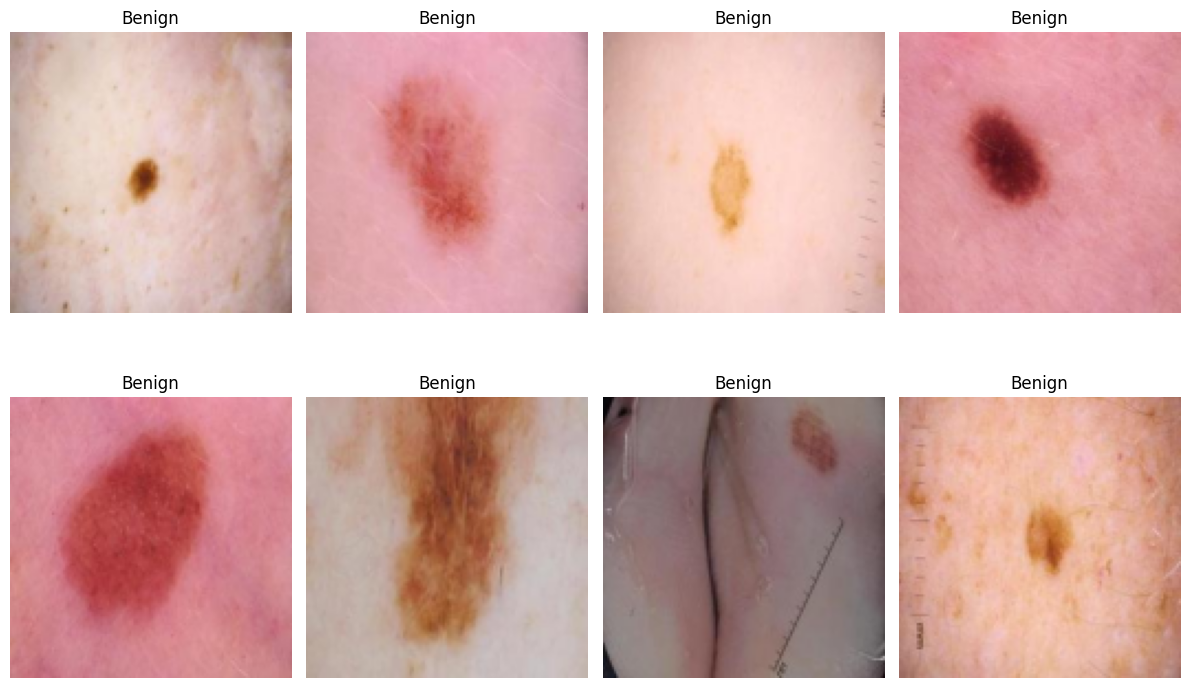

In [8]:
plt.figure(figsize=(12, 8))

for i in range(8):
    row = train_df.iloc[i]
    image = preprocess_image(row["path"])

    plt.subplot(2, 4, i + 1)
    plt.imshow(image)
    plt.title(row["class_name"])
    plt.axis("off")

plt.tight_layout()
plt.show()


##  Build the Same CNN Architecture Used in Day 4

We keep the CNN architecture consistent with the Week 8 Day 4 model:

- Conv2D(32) + MaxPooling
- Conv2D(64) + MaxPooling
- Flatten
- Dense(128)
- Dropout(0.3)
- Sigmoid output

The output is a **malignant probability** between 0 and 1.


In [9]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(IMG_SIZE[1], IMG_SIZE[0], 3)),

    Conv2D(32, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

##  Train the CNN


For the final project, the saved/best checkpoint from Day 4 can be loaded instead of retraining.


In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)


Epoch 1/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 24s 45ms/step - accuracy: 0.7965 - loss: 0.4376 - val_accuracy: 0.8493 - val_loss: 0.3589
Epoch 2/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8401 - loss: 0.3549 - val_accuracy: 0.8565 - val_loss: 0.3346
Epoch 3/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.8483 - loss: 0.3459 - val_accuracy: 0.8565 - val_loss: 0.3402
Epoch 4/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.8578 - loss: 0.3203 - val_accuracy: 0.8687 - val_loss: 0.3040
Epoch 5/5
297/297 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.8660 - loss: 0.3089 - val_accuracy: 0.8805 - val_loss: 0.2993


##  Plot Training History

Training and validation curves help us check whether the model appears to be learning consistently or whether there are signs of overfitting.


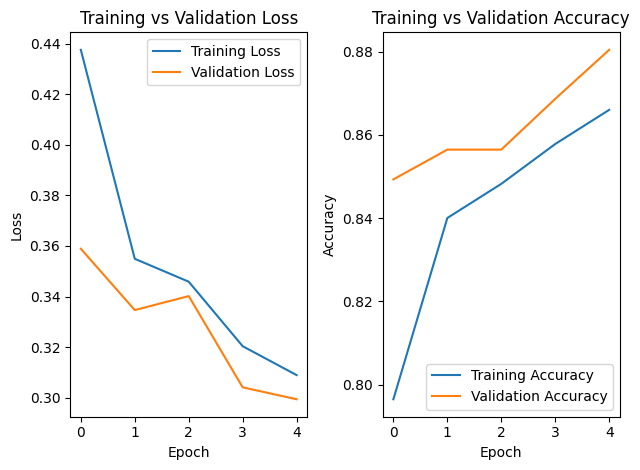

In [11]:
history_df = pd.DataFrame(history.history)
plt.subplot(1, 2, 1)
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_df["accuracy"], label="Training Accuracy")
plt.plot(history_df["val_accuracy"], label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


#  Full Test Evaluation

Now we evaluate the model on the untouched test set.
For a binary medical-image classification task, we should not rely on accuracy alone.
We report:
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion matrix

The positive class is **Malignant**.


In [12]:
test_probabilities = model.predict(test_ds, verbose=0).ravel()
y_test = test_df["label"].to_numpy()
DEFAULT_THRESHOLD = 0.50
test_predictions = (test_probabilities >= DEFAULT_THRESHOLD).astype(int)
accuracy = accuracy_score(y_test, test_predictions)
precision = precision_score(y_test, test_predictions, pos_label=1, zero_division=0)
recall = recall_score(y_test, test_predictions, pos_label=1, zero_division=0)
f1 = f1_score(y_test, test_predictions, pos_label=1, zero_division=0)
roc_auc = roc_auc_score(y_test, test_probabilities)
pr_auc = average_precision_score(y_test, test_probabilities)
metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Malignant)", "Recall (Malignant)", "F1 (Malignant)", "ROC-AUC", "PR-AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc, pr_auc]
})
display(metrics_df.style.format({"Value": "{:.4f}"}))


,Metric,Value
0,Accuracy,0.8755
1,Precision (Malignant),0.9243
2,Recall (Malignant),0.8180
3,F1 (Malignant),0.8679
4,ROC-AUC,0.9517
5,PR-AUC,0.9445


##  Classification Report

The classification report gives per-class precision, recall, and F1-score.

Pay special attention to the **Malignant recall** because a false negative means a malignant image was classified as benign.


In [13]:
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


              precision    recall  f1-score   support

      Benign     0.8368    0.9330    0.8823      1000
   Malignant     0.9243    0.8180    0.8679      1000

    accuracy                         0.8755      2000
   macro avg     0.8805    0.8755    0.8751      2000
weighted avg     0.8805    0.8755    0.8751      2000



##  Confusion Matrix

For this binary problem:

- **TN:** Benign → Benign
- **FP:** Benign → Malignant
- **FN:** Malignant → Benign
- **TP:** Malignant → Malignant

The false-negative count is particularly important for our error analysis.


True Negatives : 933
False Positives: 67
False Negatives: 182
True Positives : 818


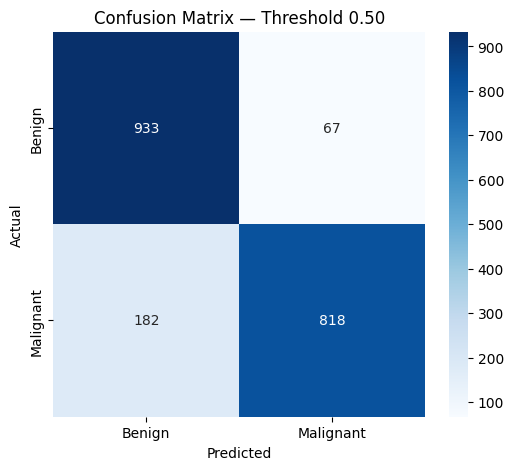

In [14]:
cm = confusion_matrix(y_test, test_predictions)
tn, fp, fn, tp = cm.ravel()
print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=CLASS_NAMES,yticklabels=CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Threshold 0.50")
plt.show()


## Interpret the Main Error

The most important question is not only:

> How accurate is the model?

It is also:

> **What type of mistake does the model make most often?**

If false negatives are high, the model is missing malignant cases.

This does not automatically mean the model is unusable; it means the operating threshold and/or model training strategy should be investigated further.


In [15]:
error_counts = pd.Series({
    "False Positives": fp,
    "False Negatives": fn
})

display(error_counts.to_frame("Count"))

if fn > fp:
    print("Main error type: False Negatives")
    print("The model misses more malignant cases than it falsely flags as malignant.")
elif fp > fn:
    print("Main error type: False Positives")
    print("The model produces more false alarms than missed malignant cases.")
else:
    print("False positives and false negatives are equal.")


,Count
False Positives,67
False Negatives,182


Main error type: False Negatives
The model misses more malignant cases than it falsely flags as malignant.


#  ROC Curve and ROC-AUC

ROC analysis evaluates the model across many classification thresholds.

The ROC curve plots:

- True Positive Rate (Recall)
- False Positive Rate

AUC summarizes the ranking ability of the model across thresholds.

A high ROC-AUC means the model generally separates the two classes well, but the selected operating threshold still matters.


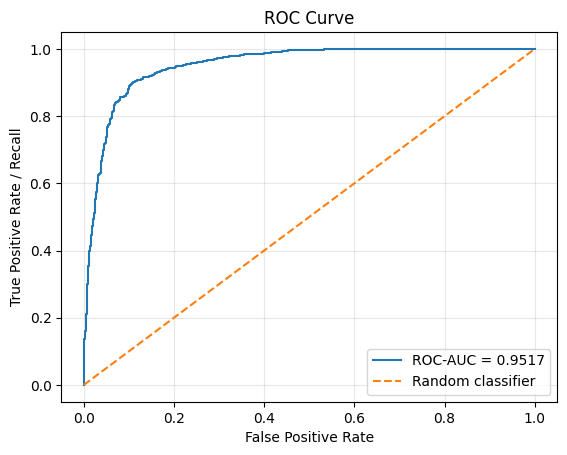

In [16]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_probabilities)
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#  Precision–Recall Curve

The Precision–Recall curve is especially useful when we care about the positive class.

Here:

**Positive = Malignant**

The curve shows how precision changes as recall changes across thresholds.

There is usually a trade-off:

- Lower threshold → higher recall, potentially lower precision.
- Higher threshold → higher precision, potentially lower recall.


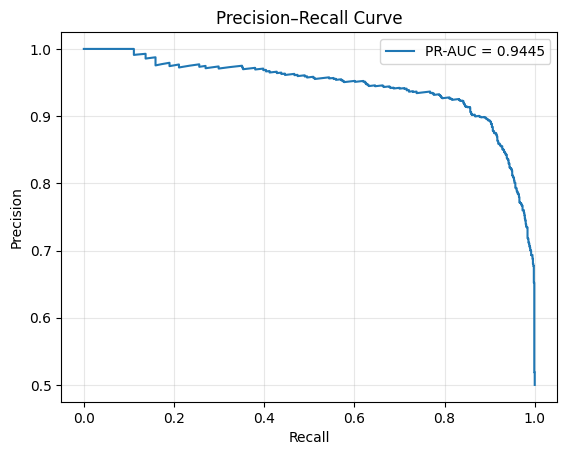

In [17]:
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test,test_probabilities)
plt.plot(pr_recall, pr_precision, label=f"PR-AUC = {pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


#  Threshold Tuning

The CNN outputs a probability, not a final class.

The default threshold is:

`0.50`

But we can deliberately choose another threshold.

For this project, threshold selection should consider the cost of missing a malignant case versus generating a false positive.

We will evaluate several candidate thresholds and compare:

- Precision
- Recall
- F1
- False Positives
- False Negatives


In [18]:
thresholds_to_test = np.arange(0.20, 0.81, 0.05)

threshold_rows = []

for threshold in thresholds_to_test:
    preds = (test_probabilities >= threshold).astype(int)

    cm_t = confusion_matrix(y_test, preds)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

    threshold_rows.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
        "False Positives": fp_t,
        "False Negatives": fn_t
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.style.format({
    "Threshold": "{:.2f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}"
}))


,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.20,0.7995,0.9570,0.8712,240,43
1,0.25,0.8292,0.9420,0.8820,194,58
2,0.30,0.8557,0.9250,0.8890,156,75
3,0.35,0.8746,0.9140,0.8939,131,86
4,0.40,0.8986,0.8860,0.8922,100,114
5,0.45,0.9117,0.8570,0.8835,83,143
6,0.50,0.9243,0.8180,0.8679,67,182
7,0.55,0.9344,0.7690,0.8437,54,231
8,0.60,0.9407,0.7140,0.8118,45,286
9,0.65,0.9449,0.6520,0.7716,38,348


##  Visualize the Threshold Trade-off

This plot makes the decision easier to communicate,the goal is not simply to maximize one metric blindly,instead, we choose an operating point that matches the project's priorities.


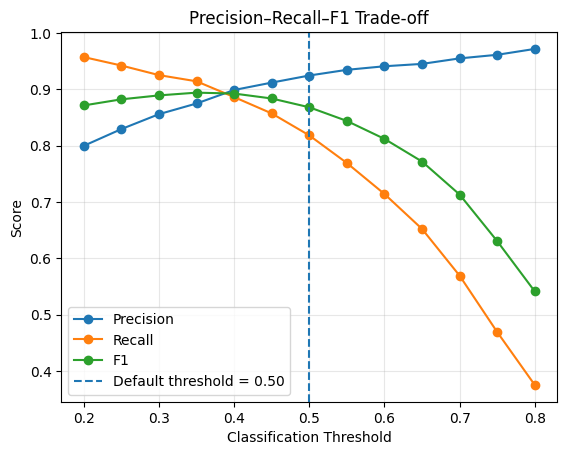

In [19]:
plt.plot(threshold_df["Threshold"], threshold_df["Precision"], marker="o", label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], marker="o", label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], marker="o", label="F1")
plt.axvline(0.50, linestyle="--", label="Default threshold = 0.50")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall–F1 Trade-off")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


##  Select a Candidate Operating Threshold

For this educational project, we select the threshold with the highest F1-score as a transparent starting rule.


In [20]:
best_row = threshold_df.loc[threshold_df["F1"].idxmax()]
SELECTED_THRESHOLD = float(best_row["Threshold"])
print("Candidate threshold selected by highest F1:")
print(f"Threshold: {SELECTED_THRESHOLD:.2f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall: {best_row['Recall']:.4f}")
print(f"F1: {best_row['F1']:.4f}")
print(f"False Positives: {int(best_row['False Positives'])}")
print(f"False Negatives: {int(best_row['False Negatives'])}")


Candidate threshold selected by highest F1:
Threshold: 0.35
Precision: 0.8746
Recall: 0.9140
F1: 0.8939
False Positives: 131
False Negatives: 86


#  Reference Threshold vs Selected Threshold

For Sprint 3 review, the **0.50 threshold is our Day 4 reference operating point**.

The selected threshold is not a new model. It is the same model evaluated at a different decision threshold.

This distinction is important:

> Changing the threshold changes classification decisions, but it does not retrain the CNN.


In [21]:
baseline_preds = (test_probabilities >= 0.50).astype(int)
selected_preds = (test_probabilities >= SELECTED_THRESHOLD).astype(int)
comparison = pd.DataFrame([
    {
        "Operating Point": "Day 4 Reference",
        "Threshold": 0.50,
        "Precision": precision_score(y_test, baseline_preds, zero_division=0),
        "Recall": recall_score(y_test, baseline_preds, zero_division=0),
        "F1": f1_score(y_test, baseline_preds, zero_division=0),
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    },
    {
        "Operating Point": "Selected Threshold",
        "Threshold": SELECTED_THRESHOLD,
        "Precision": precision_score(y_test, selected_preds, zero_division=0),
        "Recall": recall_score(y_test, selected_preds, zero_division=0),
        "F1": f1_score(y_test, selected_preds, zero_division=0),
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }
])

display(comparison.style.format({
    "Threshold": "{:.2f}",
    "Precision": "{:.4f}",
    "Recall": "{:.4f}",
    "F1": "{:.4f}",
    "ROC-AUC": "{:.4f}",
    "PR-AUC": "{:.4f}"
}))


,Operating Point,Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Day 4 Reference,0.50,0.9243,0.8180,0.8679,0.9517,0.9445
1,Selected Threshold,0.35,0.8746,0.9140,0.8939,0.9517,0.9445


#  Error Analysis at the Selected Threshold

Now we identify actual misclassified images.

This connects Day 5 directly to the Day 4 error-analysis work.

We especially want to inspect:

1. False negatives — actual Malignant, predicted Benign.
2. False positives — actual Benign, predicted Malignant.


In [22]:
final_predictions = selected_preds
analysis_df = test_df.copy()
analysis_df["probability_malignant"] = test_probabilities
analysis_df["prediction"] = final_predictions
analysis_df["prediction_name"] = analysis_df["prediction"].map({
    0: "Benign",
    1: "Malignant"
})
analysis_df["error_type"] = np.select(
    [
        (analysis_df["label"] == 1) & (analysis_df["prediction"] == 0),
        (analysis_df["label"] == 0) & (analysis_df["prediction"] == 1)
    ],
    [
        "False Negative",
        "False Positive"
    ],
    default="Correct"
)

print(analysis_df["error_type"].value_counts())


error_type
Correct           1783
False Positive     131
False Negative      86
Name: count, dtype: int64


##  Display Misclassified Examples

The next cell displays a sample of false negatives and false positives.

### Interpretation

A misclassified image may reflect:

- visual similarity between classes,
- lesion appearance that is difficult for the model,
- image quality,
- lighting/background variation,
- or limitations of the current CNN.

This is qualitative analysis, not proof of the medical cause of an error.


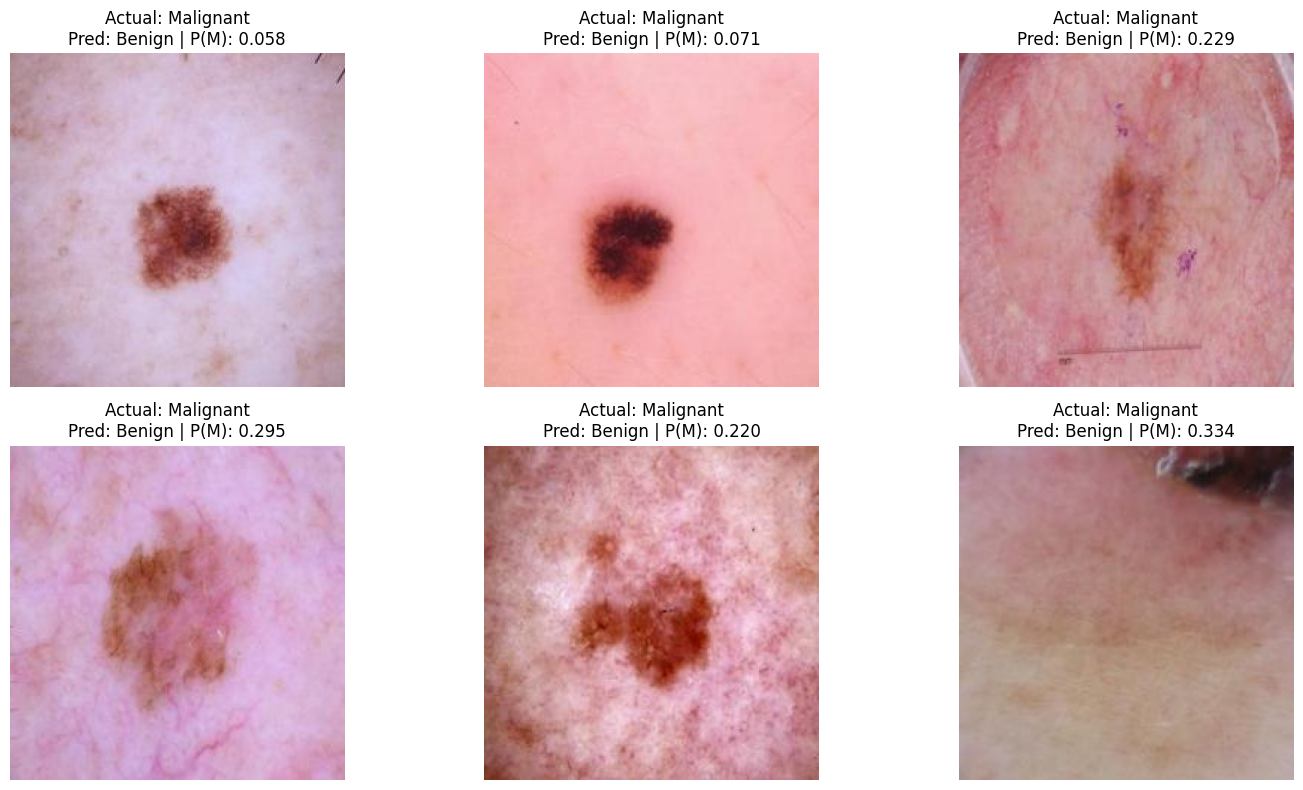

In [23]:
def show_examples(df, error_type, n=6):
    subset = df[df["error_type"] == error_type].head(n)

    if subset.empty:
        print(f"No examples found for {error_type}.")
        return

    plt.figure(figsize=(15, 8))

    for i, (_, row) in enumerate(subset.iterrows()):
        image = cv2.cvtColor(cv2.imread(row["path"]), cv2.COLOR_BGR2RGB)

        plt.subplot(2, 3, i + 1)
        plt.imshow(image)
        plt.title(
            f"Actual: {row['class_name']}\n"
            f"Pred: {row['prediction_name']} | P(M): {row['probability_malignant']:.3f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_examples(analysis_df, "False Negative", n=6)


### False Positive Examples


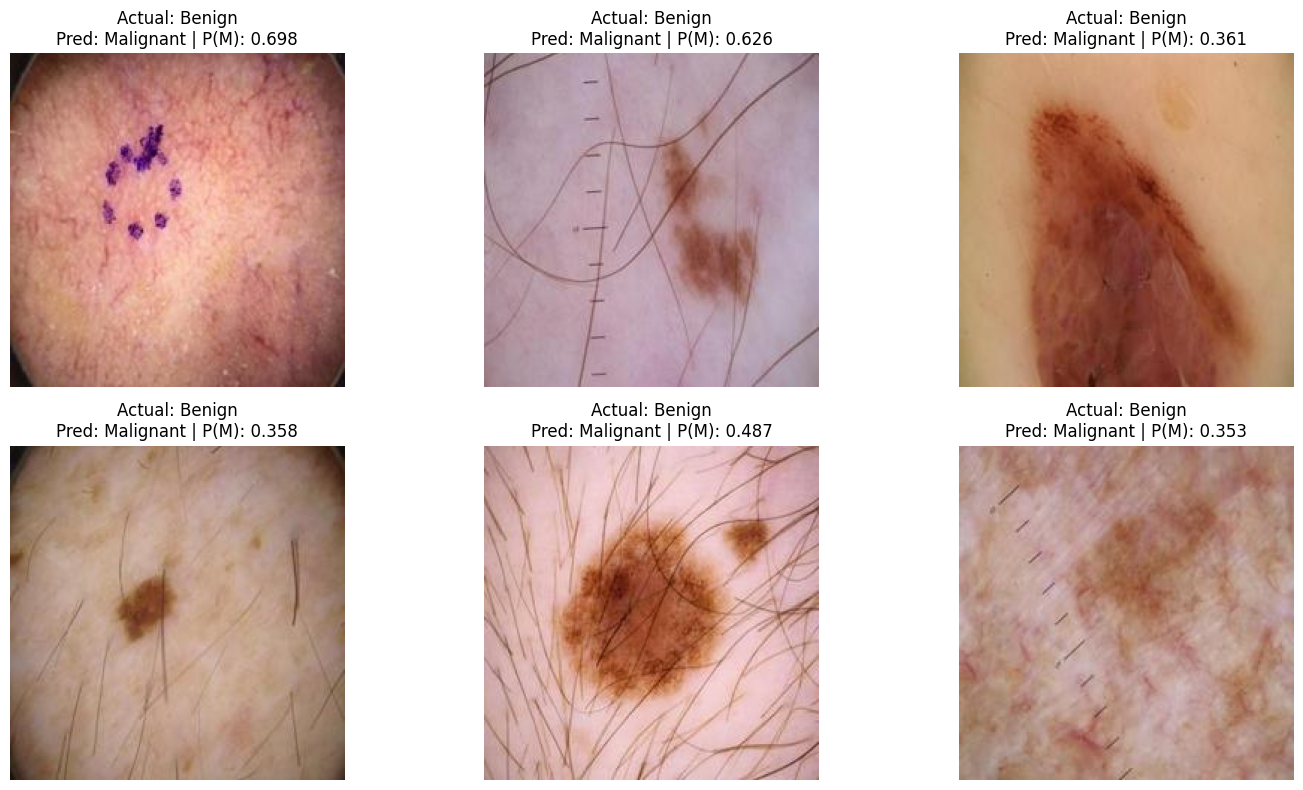

In [24]:
show_examples(analysis_df, "False Positive", n=6)


#  SHAP Explainability

## Why SHAP?

A high-performing model is easier to trust when we can inspect how it reached individual predictions.

For image models, SHAP can assign contribution values to image regions/pixels.

We will produce:

### Local explanation
Why did the model make **this specific prediction**?

### Global-style interpretation
Across several examples, which visual regions tend to contribute to the model's decisions?

> SHAP for deep image models can be computationally expensive. We therefore use a small background sample and a small number of explanation images so the notebook remains practical on Google Colab.


In [25]:
background_count = min(8, len(train_split))
explain_count = min(3, len(test_df))
background_df = train_split.sample(background_count, random_state=SEED)
background_images = np.stack([
    preprocess_image(p) for p in background_df["path"]
]).astype(np.float32)

print("SHAP background shape:", background_images.shape)


SHAP background shape: (8, 128, 128, 3)


##  Create a SHAP Gradient Explainer

`GradientExplainer` is designed for differentiable models such as neural networks.

We use the trained CNN and a small background sample.

If the installed TensorFlow/SHAP combination does not support this explainer in the current Colab runtime, the cell reports the issue rather than stopping the entire evaluation notebook.


In [26]:
shap_explainer = None
try:
    shap_explainer = shap.GradientExplainer(model, background_images)
    print("SHAP GradientExplainer created successfully.")
except Exception as e:
    print("SHAP explainer could not be created in this runtime.")
    print("Reason:", repr(e))


SHAP GradientExplainer created successfully.


#  Explain a False Negative with SHAP

A false negative is especially useful for our explainability analysis:

**Actual = Malignant**

**Predicted = Benign**

If a false negative exists, we select one and ask:

> Which image regions contributed to the model's prediction?


In [27]:
false_negative_df = analysis_df[analysis_df["error_type"] == "False Negative"]

if len(false_negative_df) == 0:
    print("No false negative is available at the selected threshold.")
    shap_example_df = analysis_df.sample(1, random_state=SEED)
else:
    shap_example_df = false_negative_df.head(1)

shap_example_path = shap_example_df.iloc[0]["path"]
shap_example_image = preprocess_image(shap_example_path)

print("Image:", shap_example_path)
print("Actual:", shap_example_df.iloc[0]["class_name"])
print("Predicted:", shap_example_df.iloc[0]["prediction_name"])
print("Malignant probability:", round(float(shap_example_df.iloc[0]["probability_malignant"]), 4))


Image: /root/.cache/kagglehub/datasets/ailearner-researchlab/melanoma-skin-cancer-dataset-benign-vs-malignant/versions/1/test/Malignant/6110.jpg
Actual: Malignant
Predicted: Benign
Malignant probability: 0.0579


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(1, 128, 128, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(50, 128, 128, 3))']
  warnings.warn(msg)


SHAP values shape: (128, 128, 3)


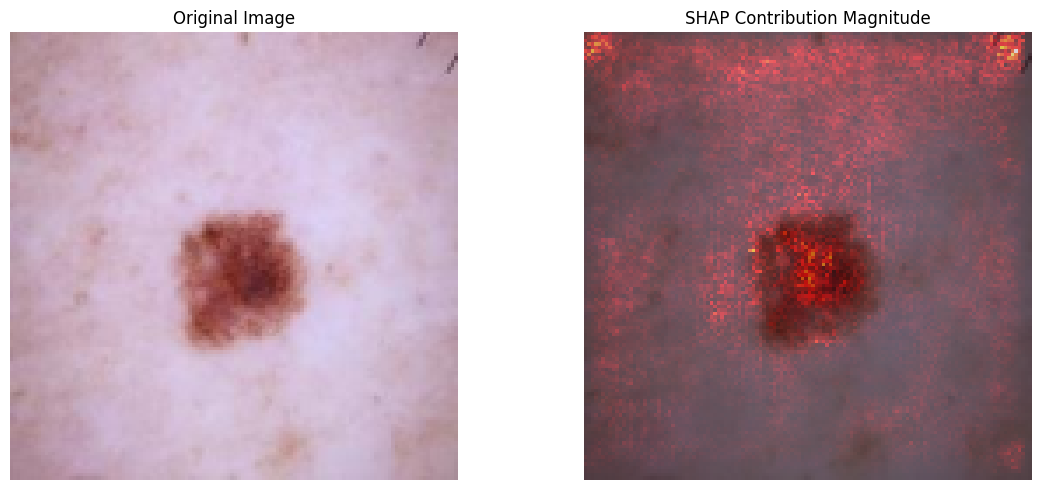

In [28]:
if shap_explainer is not None:
    try:
        shap_values = shap_explainer(
            np.expand_dims(shap_example_image, axis=0)
        )
        if isinstance(shap_values, list):
            sv = shap_values[0]
        elif hasattr(shap_values, "values"):
            sv = shap_values.values
        else:
            sv = shap_values

        sv = np.asarray(sv)
        while sv.ndim > 4:
            sv = np.squeeze(sv, axis=-1)

        if sv.ndim == 4:
            sv = sv[0]

        print("SHAP values shape:", sv.shape)
        shap_magnitude = np.abs(sv).mean(axis=-1)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(shap_example_image)
        plt.title("Original Image")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(shap_example_image)
        plt.imshow(shap_magnitude, cmap="hot", alpha=0.55)
        plt.title("SHAP Contribution Magnitude")
        plt.axis("off")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print("SHAP visualization could not be generated.")
        print("Reason:", repr(e))
else:
    print("Skipping SHAP visualization because the explainer was unavailable.")


##  SHAP Interpretation

The SHAP visualization should be interpreted as an explanation of the model's learned decision.
For a specific image:
- Regions with stronger contribution values had a greater influence on the model's output.
- Positive/negative direction depends on the model output convention and SHAP version.
- The visualization does not prove that a highlighted region is medically diagnostic.

The goal is model transparency: understanding which visual information the network relied on.


#  Small Global SHAP Study

A single SHAP explanation is local.
To obtain a broader view, we explain a small set of test images and aggregate the absolute SHAP magnitude across them.
This is a practical **global-style feature-region analysis** for an image model.
Because image SHAP is expensive, we intentionally keep the sample small.


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(3, 128, 128, 3))']
  warnings.warn(msg)


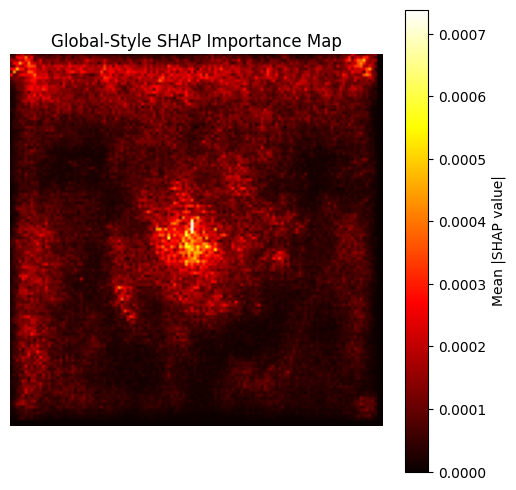

Global-style SHAP map generated from 3 images.


In [29]:
global_shap_values = []
if shap_explainer is not None:
    try:
        global_paths = test_df.sample(
            min(3, len(test_df)),
            random_state=SEED
        )["path"].tolist()

        global_images = np.stack([
            preprocess_image(p) for p in global_paths
        ]).astype(np.float32)

        raw_global = shap_explainer(global_images)

        if isinstance(raw_global, list):
            global_sv = np.asarray(raw_global[0])
        elif hasattr(raw_global, "values"):
            global_sv = np.asarray(raw_global.values)
        else:
            global_sv = np.asarray(raw_global)
        if global_sv.ndim == 5:
            global_sv = global_sv[..., 0]
        if global_sv.ndim == 4:
            global_importance_map = np.abs(global_sv).mean(axis=(0, 3))

            plt.figure(figsize=(6, 6))
            plt.imshow(global_importance_map, cmap="hot")
            plt.colorbar(label="Mean |SHAP value|")
            plt.title("Global-Style SHAP Importance Map")
            plt.axis("off")
            plt.show()

            print("Global-style SHAP map generated from", len(global_paths), "images.")
        else:
            print("Unexpected SHAP shape:", global_sv.shape)

    except Exception as e:
        print("Global SHAP analysis could not be completed.")
        print("Reason:", repr(e))
else:
    print("Skipping global SHAP because the explainer was unavailable.")


# Communicating the Results

The model analyzes a skin-lesion image and predicts the probability of it being malignant. We evaluated its performance using precision, recall, F1-score, ROC-AUC, and PR-AUC, while also analyzing false positives and false negatives. Since missing a malignant case is more critical, we tested different thresholds and selected a threshold that improves malignant recall while maintaining a good balance with precision.
SHAP was also used to visualize which image regions contributed to individual predictions.


#  Final Evaluation Summary

The following table collects the main Sprint 3 evaluation results.
This is the table to use during the Sprint Review.


In [30]:
final_cm = confusion_matrix(y_test, selected_preds)
final_tn, final_fp, final_fn, final_tp = final_cm.ravel()
final_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision — Malignant",
        "Recall — Malignant",
        "F1 — Malignant",
        "ROC-AUC",
        "PR-AUC",
        "False Positives",
        "False Negatives"
    ],
    "Value": [
        accuracy_score(y_test, selected_preds),
        precision_score(y_test, selected_preds, zero_division=0),
        recall_score(y_test, selected_preds, zero_division=0),
        f1_score(y_test, selected_preds, zero_division=0),
        roc_auc,
        pr_auc,
        final_fp,
        final_fn
    ]
})

display(final_summary.style.format({
    "Value": lambda x: f"{x:.4f}" if isinstance(x, (float, np.floating)) else f"{int(x)}"
}))


,Metric,Value
0,Accuracy,0.8915
1,Precision — Malignant,0.8746
2,Recall — Malignant,0.9140
3,F1 — Malignant,0.8939
4,ROC-AUC,0.9517
5,PR-AUC,0.9445
6,False Positives,131.0000
7,False Negatives,86.0000


# Independent Metrics Log

This cell saves the Day 5 evaluation results independently in CSV and JSON formats.
The reference point is the same CNN at threshold 0.50.

In [31]:

def collect_metrics_row(name, threshold, predictions):
    cm_row = confusion_matrix(y_test, predictions)
    tn_row, fp_row, fn_row, tp_row = cm_row.ravel()
    return {
        "model": "CNN",
        "operating_point": name,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_test, predictions)),
        "precision_malignant": float(precision_score(y_test, predictions, pos_label=1, zero_division=0)),
        "recall_malignant": float(recall_score(y_test, predictions, pos_label=1, zero_division=0)),
        "f1_malignant": float(f1_score(y_test, predictions, pos_label=1, zero_division=0)),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "true_negatives": int(tn_row),
        "false_positives": int(fp_row),
        "false_negatives": int(fn_row),
        "true_positives": int(tp_row)
    }

metrics_log = pd.DataFrame([
    collect_metrics_row(
        "Reference Threshold",
        DEFAULT_THRESHOLD,
        baseline_preds
    ),
    collect_metrics_row(
        "Selected Threshold",
        SELECTED_THRESHOLD,
        selected_preds
    )
])

metrics_log.to_csv("day5_metrics_log.csv", index=False)
metrics_log.to_json("day5_metrics_log.json", orient="records", indent=2)

print("Saved: day5_metrics_log.csv")
print("Saved: day5_metrics_log.json")
display(metrics_log.style.format({
    "threshold": "{:.2f}",
    "accuracy": "{:.4f}",
    "precision_malignant": "{:.4f}",
    "recall_malignant": "{:.4f}",
    "f1_malignant": "{:.4f}",
    "roc_auc": "{:.4f}",
    "pr_auc": "{:.4f}"
}))


Saved: day5_metrics_log.csv
Saved: day5_metrics_log.json


,model,operating_point,threshold,accuracy,precision_malignant,recall_malignant,f1_malignant,roc_auc,pr_auc,true_negatives,false_positives,false_negatives,true_positives
0,CNN,Reference Threshold,0.50,0.8755,0.9243,0.8180,0.8679,0.9517,0.9445,933,67,182,818
1,CNN,Selected Threshold,0.35,0.8915,0.8746,0.9140,0.8939,0.9517,0.9445,869,131,86,914


# Sprint 3 Review

## What was completed?

### Model and pipeline
- Reused the Day 4 CNN architecture.
- Kept the shared preprocessing pipeline.
- Maintained the Benign/Malignant class mapping.
- Generated probability-based predictions.

### Evaluation
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC
- Confusion matrix
- False-positive / false-negative analysis

### Threshold analysis
- Compared multiple thresholds.
- Examined precision–recall trade-off.
- Selected a transparent candidate threshold using F1 as the selection rule.

### Explainability
- Generated SHAP explanations where supported.
- Produced a local explanation.
- Attempted a small global-style SHAP analysis.

### Error analysis
- Inspected false negatives and false positives.
- Focused on false negatives because they represent malignant cases predicted as benign.


#  Sprint 3 Retrospective

## What went well?

- The project now has an end-to-end image classification workflow.
- Preprocessing and prediction use the same logic.
- Evaluation goes beyond accuracy.
- Error analysis identifies the main failure modes.
- Threshold tuning makes the decision rule explicit.
- SHAP adds model explainability.

## What could be improved?

- The CNN can still produce false negatives.
- Threshold selection should be validated with domain requirements.
- Image augmentation and class-weighting strategies can be investigated further.
- Transfer learning could provide a stronger image representation.
- Explainability methods should be tested for stability across more samples.

## One concrete change for Sprint 4

The next sprint should package the preprocessing and trained model into a usable prediction interface, preserve the exact preprocessing used during training, and document limitations clearly.


#  Sprint 4 Preview — Deployment & Final Polish

The transition is:

**Sprint 3**

`Preprocessing → CNN → Evaluation → Error Analysis → Explainability`

**Sprint 4**

`Saved Model → Prediction API / App → User Input → Same Preprocessing → Prediction → Documentation`

The most important engineering requirement is to keep the serving pipeline identical to the validated training pipeline.


#  Final Conclusion

Sprint 3 is complete when the model is not only trained, but also **measured, inspected, explained, and documented**.

The final result should answer four questions:

1. **How well does the model perform?**
2. **What mistakes does it make?**
3. **Why did it make a particular prediction?**
4. **What is the next engineering step?**



